<a href="https://colab.research.google.com/github/europecodingschool/ECS---VB---YZ---08.26/blob/main/VB_YZ_Ders_18_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [7]:
df = pd.read_csv("/content/musteri_segment.csv")

In [8]:
df.head()

,musteri_id,yas,yillik_gelir,aylik_harcama,aylik_ziyaret
0,M1001,31,534,6450,2
1,M1002,64,201,4530,18
2,M1003,46,656,7810,3
3,M1004,21,158,2080,6
4,M1005,64,376,4240,16


Bir market zinciri müşteri dataseti. Sadakat kart üzerinden alınan bir data. pazarlama ekibi müşterileri segmente edip ona göre de kampanyanlar yapmak istiyor.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   musteri_id     300 non-null    object
 1   yas            300 non-null    int64 
 2   yillik_gelir   300 non-null    int64 
 3   aylik_harcama  300 non-null    int64 
 4   aylik_ziyaret  300 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 11.8+ KB


In [12]:
df.describe()

,yas,yillik_gelir,aylik_harcama,aylik_ziyaret
count,300.000000,300.000000,300.000000,300.000000
mean,41.573333,453.593333,5534.366667,6.913333
std,16.197711,270.615911,3964.890978,4.188592
min,18.000000,115.000000,750.000000,1.000000
25%,26.000000,215.250000,1880.000000,3.000000
50%,40.000000,353.500000,4270.000000,7.000000
75%,53.000000,620.000000,7942.500000,9.000000
max,75.000000,1186.000000,16110.000000,18.000000


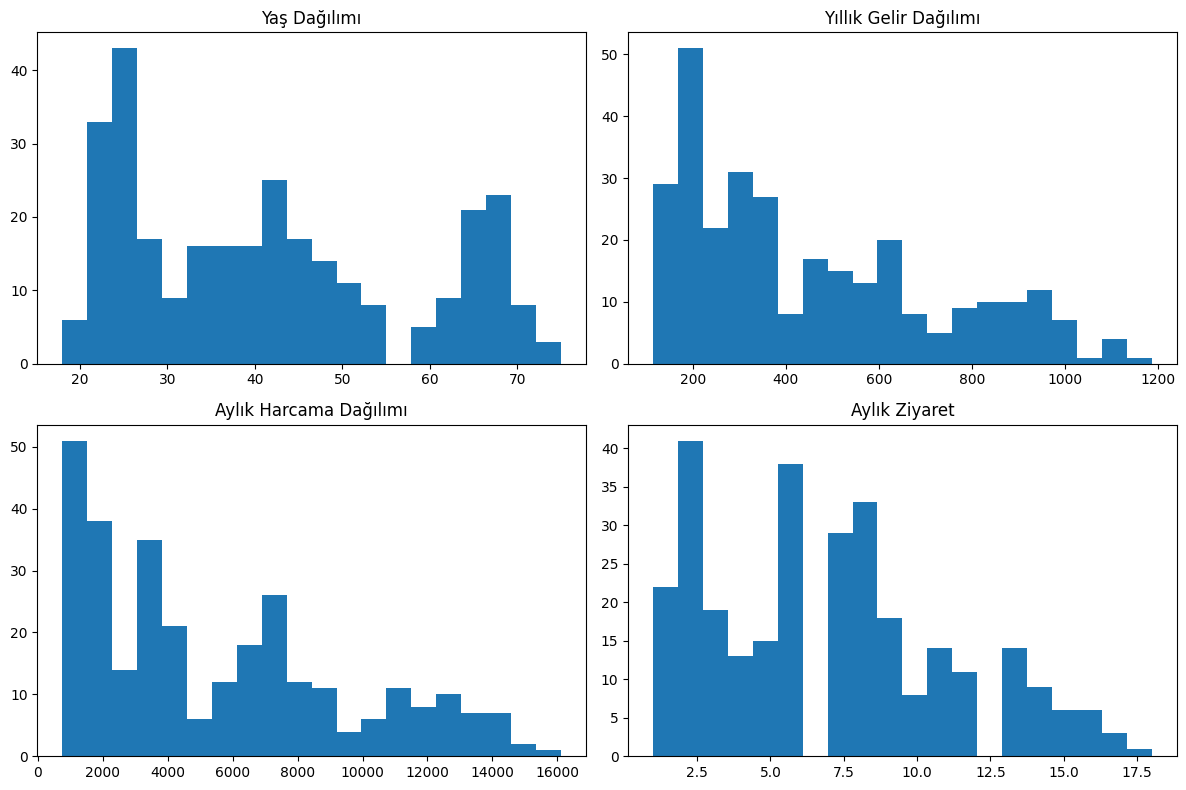

In [14]:
# Dağılımları İnceleyelim. Yaş ve yıllık gelir. histogram çiziniz.

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.hist(df["yas"], bins=20)
plt.title("Yaş Dağılımı")

plt.subplot(2,2,2)
plt.hist(df["yillik_gelir"], bins=20)
plt.title("Yıllık Gelir Dağılımı")

plt.subplot(2,2,3)
plt.hist(df["aylik_harcama"], bins=20)
plt.title("Aylık Harcama Dağılımı")

plt.subplot(2,2,4)
plt.hist(df["aylik_ziyaret"], bins=20)
plt.title("Aylık Ziyaret")

plt.tight_layout()
plt.show()



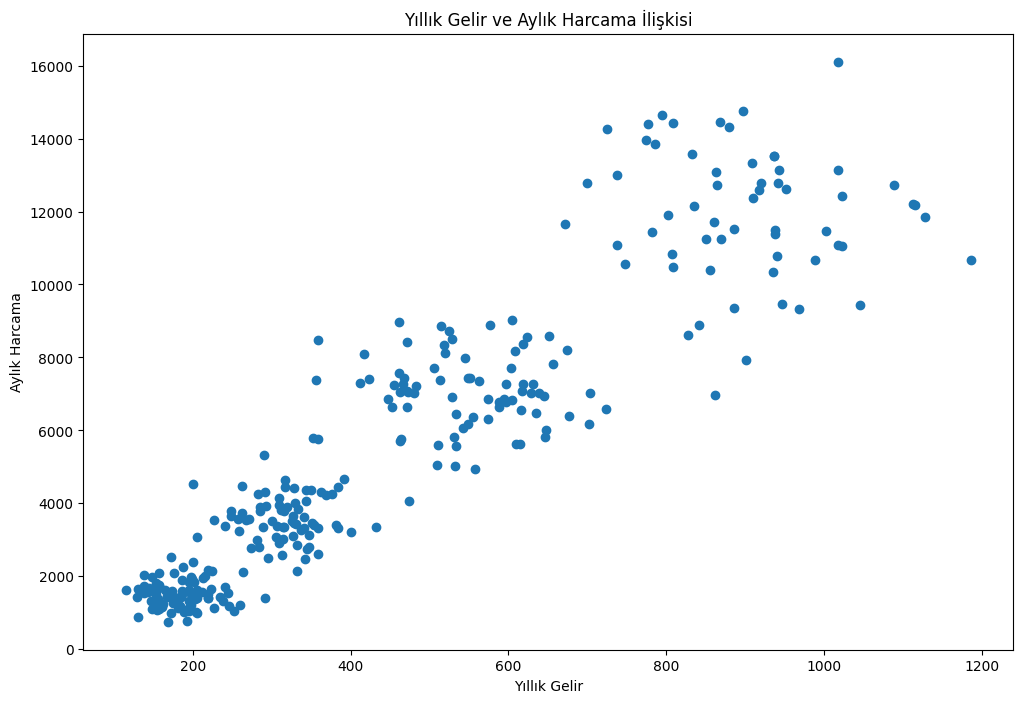

In [16]:
#scatter çizdirin. yıllık gelir aylık harcama ilişkisi

plt.figure(figsize=(12,8))
plt.scatter(df["yillik_gelir"], df["aylik_harcama"])
plt.xlabel("Yıllık Gelir")
plt.ylabel("Aylık Harcama")
plt.title("Yıllık Gelir ve Aylık Harcama İlişkisi")
plt.show()

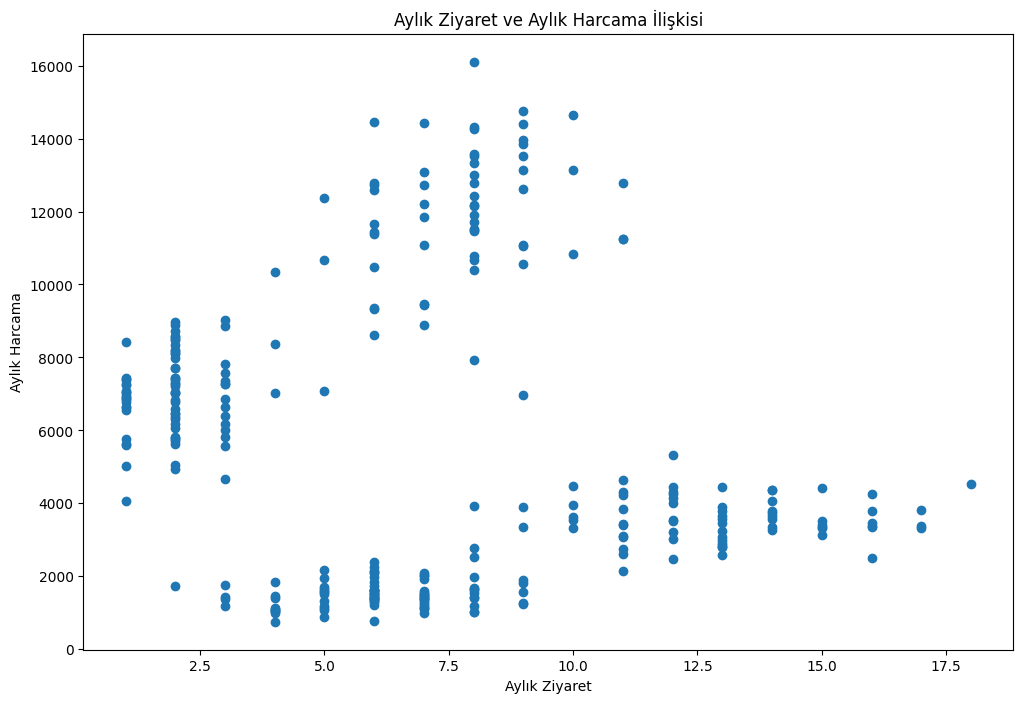

In [18]:
# Aylık ziyaret sayısı ile aylık harcama ilişkisi scatter çizin.

plt.figure(figsize=(12,8))
plt.scatter(df["aylik_ziyaret"], df["aylik_harcama"])
plt.xlabel("Aylık Ziyaret")
plt.ylabel("Aylık Harcama")
plt.title("Aylık Ziyaret ve Aylık Harcama İlişkisi")
plt.show()
#

In [20]:
# Datamızı Ölçeklendirmemiz Gerekiyor. (mesafe tabanlı bir hesaplama olduğu için kullanılacak algoritma)

X = df[["yas","yillik_gelir", "aylik_harcama", "aylik_ziyaret"]]
scaler = StandardScaler()
X_olcekli = scaler.fit_transform(X)
#

In [22]:
X_olcekli[:3]

array([[-0.6538578 ,  0.29762113,  0.23132117, -1.17498737],
       [ 1.38687115, -0.9349612 , -0.25373833,  2.65129444],
       [ 0.27374627,  0.74919784,  0.57490498, -0.93584476]])

In [25]:
#Temel K-means Modeli

temel_model = KMeans(n_clusters=3, random_state=42)
df["temel_kume"] = temel_model.fit_predict(X_olcekli)

n_cluster: verinin kaç kümeye ayrılacağı, yani k değeri. K-means bizim vermemiz gerekiyor.

fit_predict: tek satırda hem modeli eğitmeyi hemde küme etiketini vermesini sağlıyor.

In [28]:
# Modelin bize verdikleri.
df["temel_kume"].value_counts().sort_index()

,count
temel_kume,
0,160
1,60
2,80


In [29]:
temel_siluet = silhouette_score(X_olcekli, df["temel_kume"])
temel_db = davies_bouldin_score(X_olcekli, df["temel_kume"])
temel_ch = calinski_harabasz_score(X_olcekli, df["temel_kume"])

print("Silüet Score", temel_siluet)
print("Davies Bouldin Score", temel_db)
print("Calinski Harabasz Score", temel_ch)
#

Silüet Score 0.45853912142060116
Davies Bouldin Score 0.8450290269723045
Calinski Harabasz Score 208.53539625817248


Silüet Score:Nokta kendi kümesine yakın, diğer kümeler uzak mı. -1, +1 değer alıyor. Büyükse iyi.+1 e ne kadar yakınsa o kadar iyi. (en önemli başarı kriteri)

Davies-Bouldin: kümeler bir birine ne kadar benziyor? 0 yakını iyi.

Calinski Harabasz: Kümeler arası ayrıklı ve küme içi dağınıklık. Büyük değer daha iyi. genel de iki modele bakılırken bakılıyor.

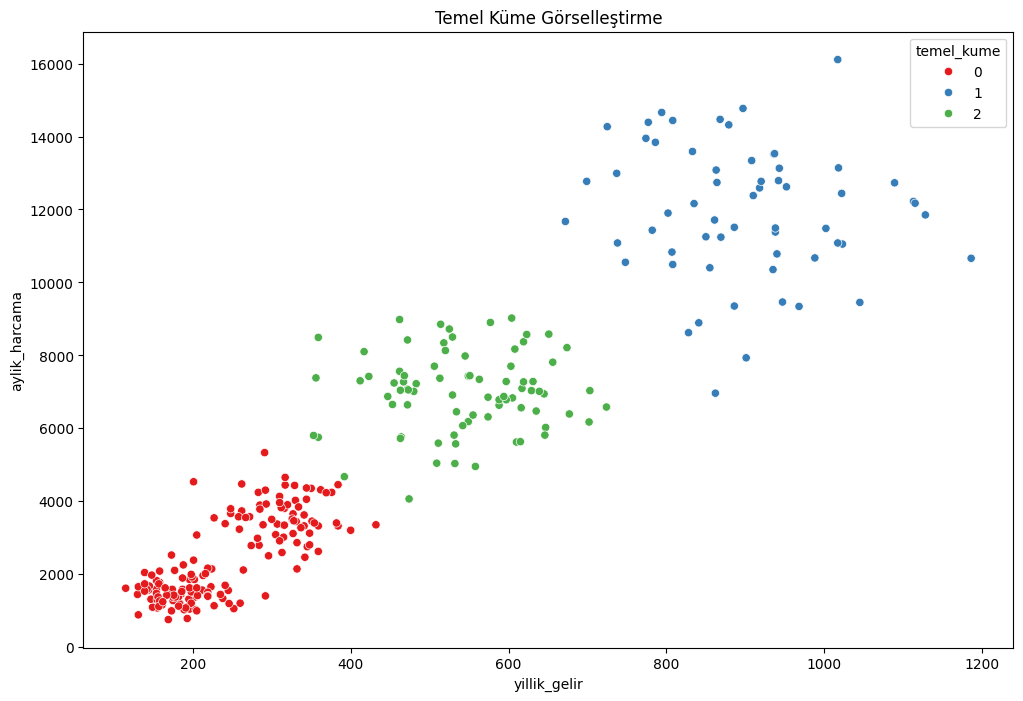

In [31]:
plt.figure(figsize=(12,8))
sns.scatterplot(x="yillik_gelir", y="aylik_harcama", hue="temel_kume", data=df, palette="Set1")
plt.title("Temel Küme Görselleştirme")
plt.show()
#

In [33]:
k_degerleri = [2,3,4,5,6,7,8,9,10]
inertia_listesi=[]
siluet_degerleri = []
db_degerleri = []
ch_degerleri = []

for k in k_degerleri:
  model = KMeans(n_clusters=k, random_state=42)
  etiketler = model.fit_predict(X_olcekli)

  siluet = silhouette_score(X_olcekli, etiketler)
  db = davies_bouldin_score(X_olcekli, etiketler)
  ch = calinski_harabasz_score(X_olcekli, etiketler)

  inertia_listesi.append(model.inertia_)
  siluet_degerleri.append(siluet)
  db_degerleri.append(db)
  ch_degerleri.append(ch)

  print("k=",k,"inertia:", model.inertia_, "Siluet:", siluet, "Davies Bouldin:", db, "Calinski Harabasz:", ch)
#

k= 2 inertia: 684.4409473064751 Siluet: 0.4497948309582002 Davies Bouldin: 1.1013828545081557 Calinski Harabasz: 224.4702020054275
k= 3 inertia: 499.11017749944205 Siluet: 0.45853912142060116 Davies Bouldin: 0.8450290269723045 Calinski Harabasz: 208.53539625817248
k= 4 inertia: 111.31164160402881 Siluet: 0.6874286240377122 Davies Bouldin: 0.48138228366286834 Calinski Harabasz: 965.0136303249706
k= 5 inertia: 98.61933535264532 Siluet: 0.6009466239636593 Davies Bouldin: 0.6907696605664633 Calinski Harabasz: 823.639945729604
k= 6 inertia: 88.60673534856754 Siluet: 0.5318576748391534 Davies Bouldin: 1.0046797941593415 Calinski Harabasz: 737.5277252279525
k= 7 inertia: 83.44581207423339 Siluet: 0.5303458198841103 Davies Bouldin: 1.0166762559362172 Calinski Harabasz: 653.4188054303168
k= 8 inertia: 76.46737540133164 Siluet: 0.41027788943982024 Davies Bouldin: 1.2663178371997184 Calinski Harabasz: 612.9066241106269
k= 9 inertia: 73.30362428654189 Siluet: 0.4080118712266758 Davies Bouldin: 1.2

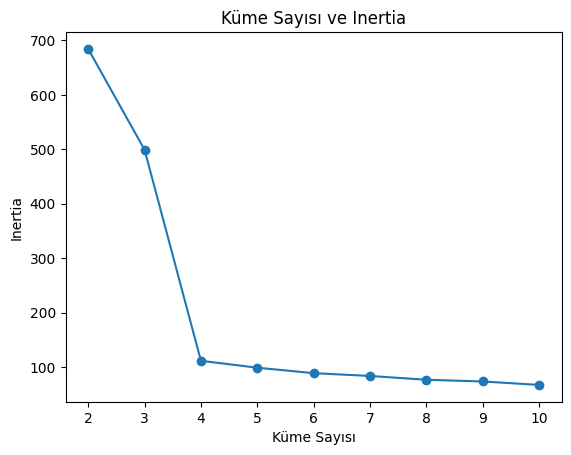

In [35]:
plt.plot(k_degerleri, inertia_listesi, marker="o")
plt.xlabel("Küme Sayısı")
plt.ylabel("Inertia")
plt.title("Küme Sayısı ve Inertia")
plt.show()  # dirsek mantığında k=2 den k=3 e düşüş sert k=3 den k=4 e düşüş sert k=4 den k=5 düşüş zayıf. k=4 dirsek değeri ve bizim k değerimiz oldu.

In [36]:
#Final Model
final_model = KMeans(n_clusters=4, random_state=42)
df["kume"] = final_model.fit_predict(X_olcekli)

print(df["kume"].value_counts().sort_index())
#
#

kume
0    90
1    60
2    80
3    70
Name: count, dtype: int64
